In [1]:
import warnings
from linear_operator.utils.warnings import NumericalWarning
from botorch.exceptions import OptimizationWarning

ignore_warnings: list[type] = [
    NumericalWarning,
    OptimizationWarning,
    RuntimeWarning
]

for warning in ignore_warnings:
    warnings.filterwarnings(action="ignore", category=warning)

In [2]:
from ddo_suite.problems import (
    Sphere, 
    ExothermicCstr,
    PidTuning,
    WilliamsOtto
    )
from ddo_suite.algorithms import (
    ALGORITHM_IDS,
    __all__,
    random_search,
    safeopt,
    goose
    )
from ddo_suite.experiments import (
    run_benchmark, 
    aggregate_results, 
    AggregatedResults,
    ExperimentCache,
    BenchmarkResults
    )

from safebo_simpl.wrappers.ddosuite_wrapper import (
    DDOSuite_AlgorithmWrapper,
    DDOSuite_ObjectiveWrapper
)
from safebo_simpl.models import *
from safebo_simpl.util.generics import SafeBOAlgorithm
from safebo_simpl.util.params import BOParams
from safebo_simpl.models.voronoi_search.Voronoi_V1 import VoronoiV1

from typing import Callable

import torch
from torch import Tensor

import numpy as np
from numpy import typing as npt

dtype: torch.dtype = torch.float64
device: torch.device = torch.device("cpu")

def _wrapper_factory[T_Algorithm: SafeBOAlgorithm, T_Params: BOParams](
    algorithm: type[T_Algorithm],
    params: T_Params,
    config_name: str = "default",
) -> tuple[DDOSuite_AlgorithmWrapper, str]:
    wrapper: DDOSuite_AlgorithmWrapper = DDOSuite_AlgorithmWrapper(
        algorithm=algorithm,
        params=params,
        dtype=dtype,   # Global scope
        device=device  # Global scope
    )
    base_name = algorithm.__name__.lower().replace(' ', '_')
    id: str = f"custom_{base_name}_{config_name}"
    return (wrapper, id)

# ----------------------------
# ------ Generic Params ------
# ----------------------------

generic_state: BOParams = BOParams()
# Sampling
generic_state.sampling.initial_candidates = 2 + 4
generic_state.sampling.batch_size = 16
generic_state.convergence.confidence_level = 3.

# Constraints
generic_state.constraints.constraints = []

# Data prms
generic_state.data.negate = False


# --------------------------
# ------ GPsTR Params ------
# --------------------------

GPsTR_state: BOParams_GPsTR = BOParams_GPsTR()
GPsTR_state.sampling = generic_state.sampling
GPsTR_state.constraints = generic_state.constraints
GPsTR_state.data = generic_state.data

pairs: list[tuple[type[SafeBOAlgorithm], BOParams]] = [
    #(GoOSEV2, generic_state),
    #(GoOSE, generic_state),
    #(SafeOpt, generic_state),
    #(GPsTR, GPsTR_state),
    (VoronoiV1, generic_state),
]

pairs_cached: list[tuple[type[SafeBOAlgorithm], BOParams]] = [
    (GoOSEV2_Baseline, generic_state),

    #(GoOSEV2_HypercubeX, generic_state),
    #(GoOSEV2_HypercubeZ, generic_state),

    #(GoOSEV2_Aoffset, generic_state),
    #(GoOSEV2_BScheduler, generic_state),

    #(GoOSEV2_topK, generic_state),

    #(GoOSEV2_DistanceFallback, generic_state),
    #(GoOSEV2_CMAES, generic_state),
]

vals: set[str] = set(ALGORITHM_IDS.values())
custom_algorithms: list[Callable] = []

cached_custom_algorithms: list[Callable] = []

for alg, state in pairs:
    wrapper, id = _wrapper_factory(algorithm=alg, params=state,)
    custom_algorithms.append(wrapper)
    ALGORITHM_IDS[wrapper] = id

for alg, state in pairs_cached:
    wrapper, id = _wrapper_factory(algorithm=alg, params=state,)
    cached_custom_algorithms.append(wrapper)
    ALGORITHM_IDS[wrapper] = id

/Users/apple/Documents/github/optimlpse-2026/projects/safebo_simple/src/safebo_simpl/models/voronoi_search/Voronoi_V1.py:206: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  label=f'Fitted Normal ($\mu$={mean:.2f}, $\sigma$={std:.2f})')
/Users/apple/Documents/github/optimlpse-2026/projects/safebo_simple/src/safebo_simpl/models/voronoi_search/Voronoi_V1.py:206: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  label=f'Fitted Normal ($\mu$={mean:.2f}, $\sigma$={std:.2f})')


Loading problems...:   0%|          | 0/1 [00:00<?, ?it/s]

Ran non-cached algorithms:  [<function goose at 0x12e8866c0>, <safebo_simpl.wrappers.ddosuite_wrapper.DDOSuite_AlgorithmWrapper object at 0x1388ced50>]
Ran Cached algorithms: [<safebo_simpl.wrappers.ddosuite_wrapper.DDOSuite_AlgorithmWrapper object at 0x1389ec980>]
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}


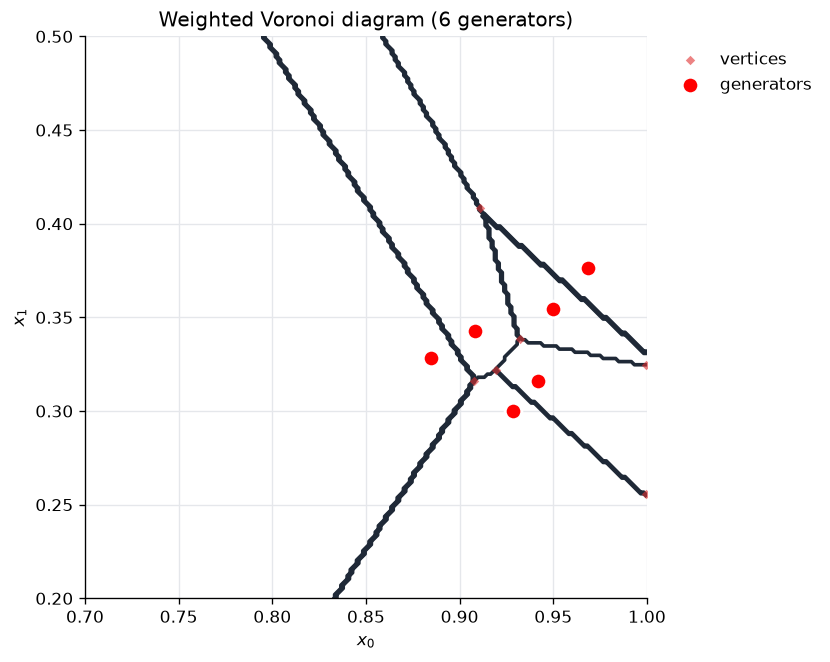

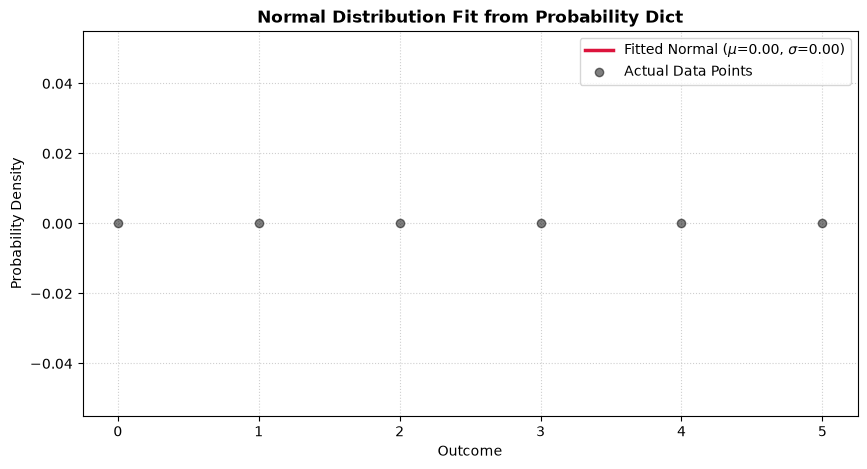

torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([Fals

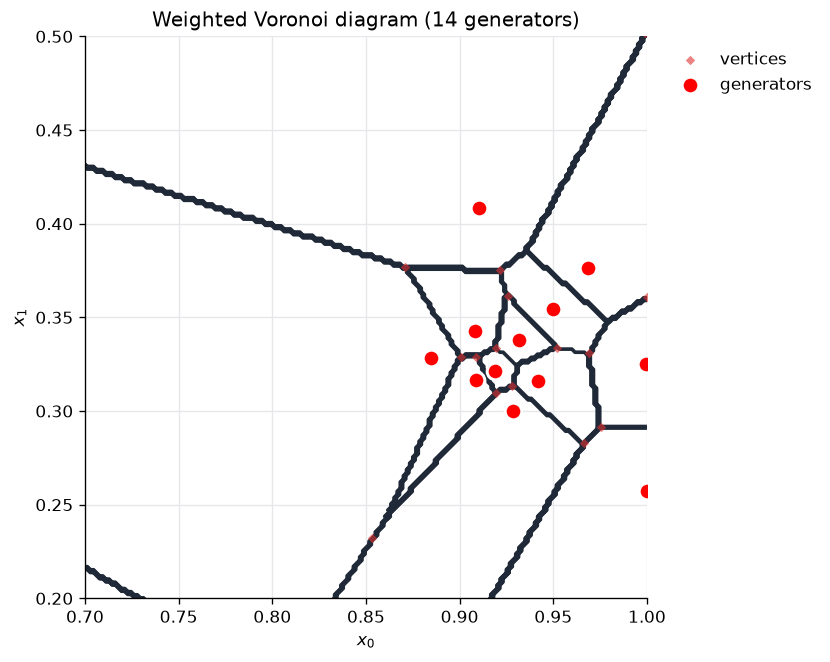

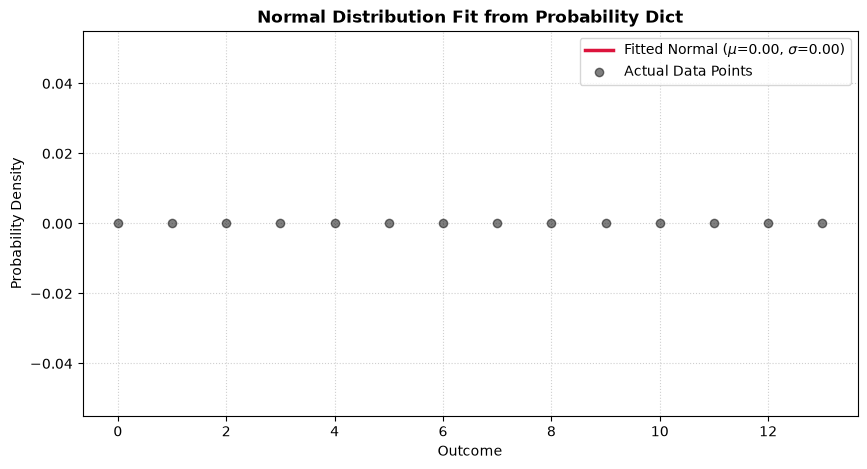

COMPUTED - problem: (williams_otto), algorithm: (custom_voronoiv1_default), seed: (0)  elapsed: 13.97 sec
  best_f: (-74.19930142711178)
  f_list: ([84.92360175466513, 108.0574514622607, 84.15183289853644, 91.75257178774359, 92.69185900515822, 75.54698980642252, 77.57052210055997, 102.25198229651357, 86.52671012907388, 95.55322761285527, 90.12188551858048, 89.09058725240459, 92.7571305737057, 104.5688152451047, 73.36821478130048, 102.84039989517419, 94.98421716101063, 85.51391362780839, 89.94684119070462, 84.10043097711798, 120.28160260799075, 95.18510911192652, 133.13779218993318, 57.02710596497843, -55.8678173496038, 166.9479934984787, 96.08601998138431, 101.27263444816856, 79.50566663739608, 93.99507830453592, 88.76656831230503, 81.6270421836615, 82.09322610460754, 92.1269612885377, 119.65244102524673, 86.29060918495395, 128.33491126417164, 51.80532908611292, -50.0096928775348, 169.79110741277418, 87.4151029456516, 107.55150489726475, 75.7056175446462, 101.73929701726831, 89.0075723

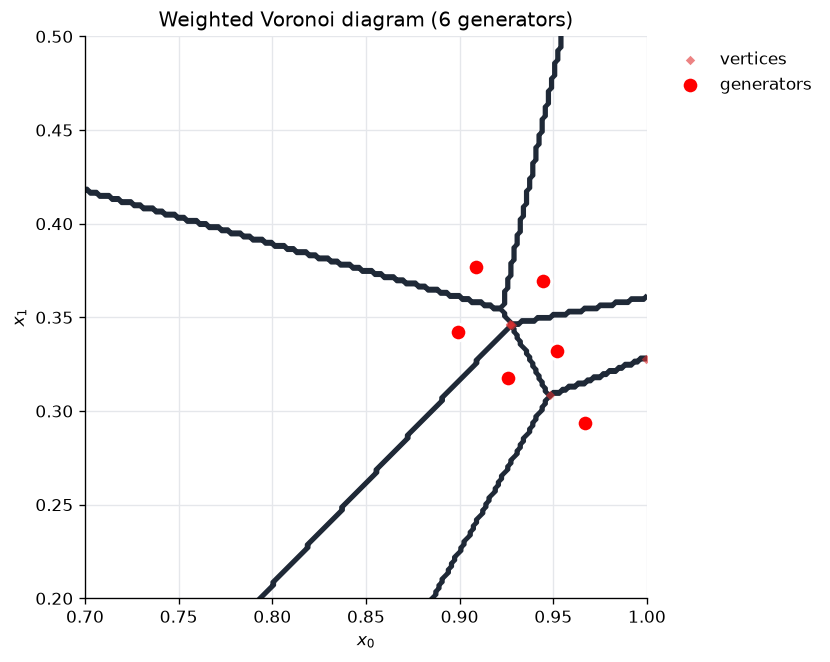

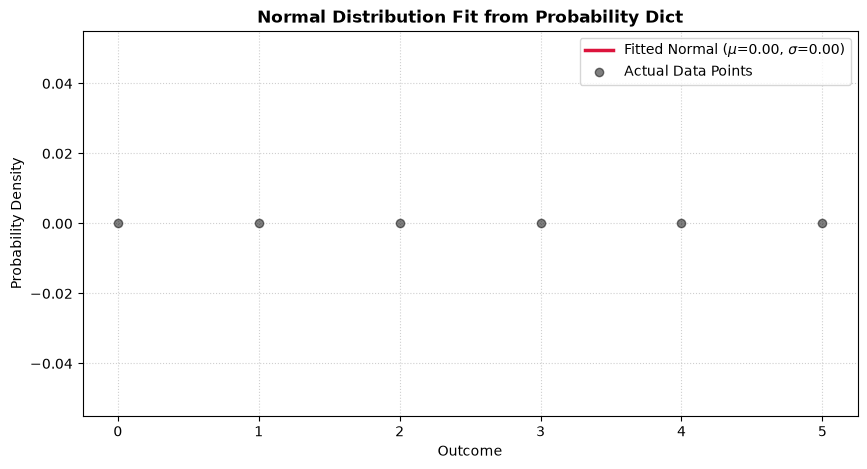

torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])
tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])


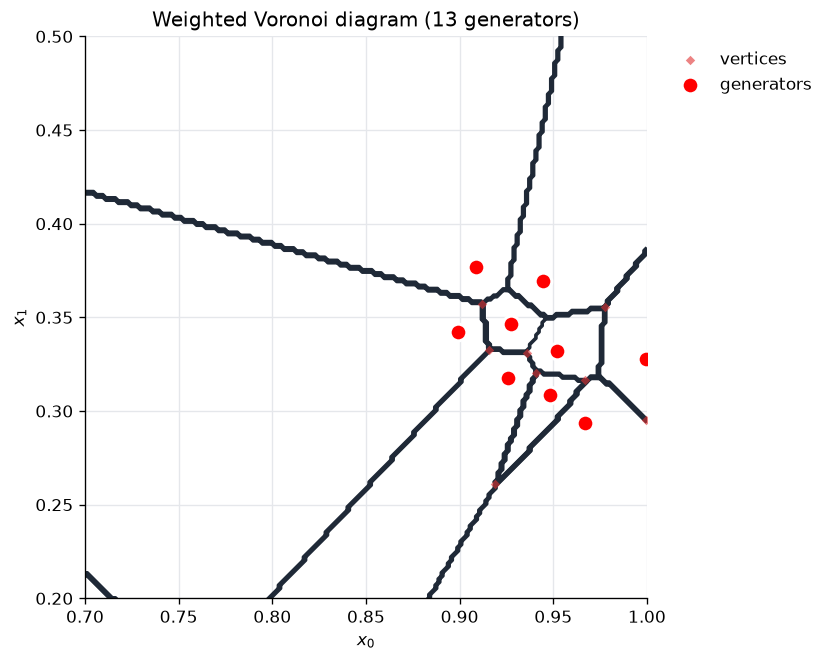

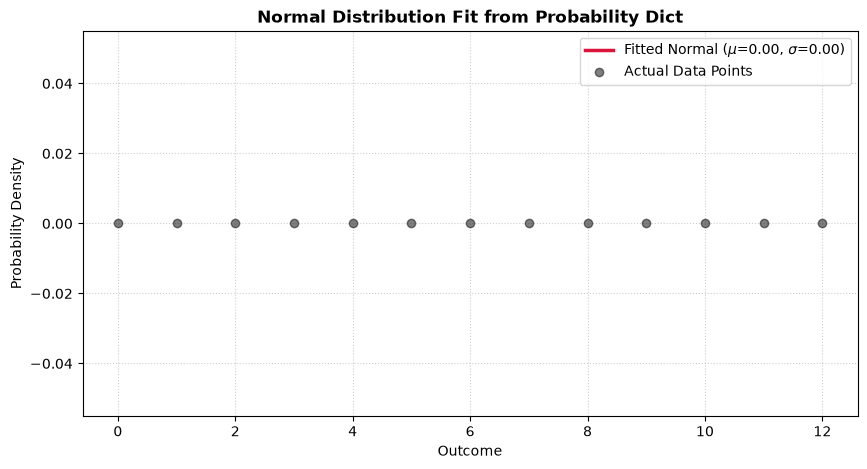

COMPUTED - problem: (williams_otto), algorithm: (custom_voronoiv1_default), seed: (1)  elapsed: 28.84 sec
  best_f: (-87.84304378468187)
  f_list: ([84.23539123328783, 113.14971695729866, 77.87660933380073, 94.7823096955808, 70.97217406439893, 85.10480216889619, 77.38411797773756, 114.2329036441738, 85.33480674029806, 94.2297028040208, 74.64588304590347, 94.4056441477519, 72.90195709630268, 114.24431035451505, 80.9970748043146, 94.76927567978771, 67.20769709925185, 94.39366815974927, 83.49439097497088, 101.33741248620231, 107.32558095183913, 133.11715785329818, -81.00545399810517, 5.222256039026661, 17.883026980921272, 82.50250310599768, 114.47925352502011, 76.89479822817009, 93.14101232392682, 74.8570303334975, 85.02842886933797, 83.44979359144497, 111.96788477028304, 100.70163651876726, 121.98589731582115, -82.07175117378915, 13.039118338630146, 23.655941417066174, 75.55205213926752, 110.7873212582067, 89.25256053224075, 92.07714421182504, 71.57661200129508, 93.39529510474551, 84.214

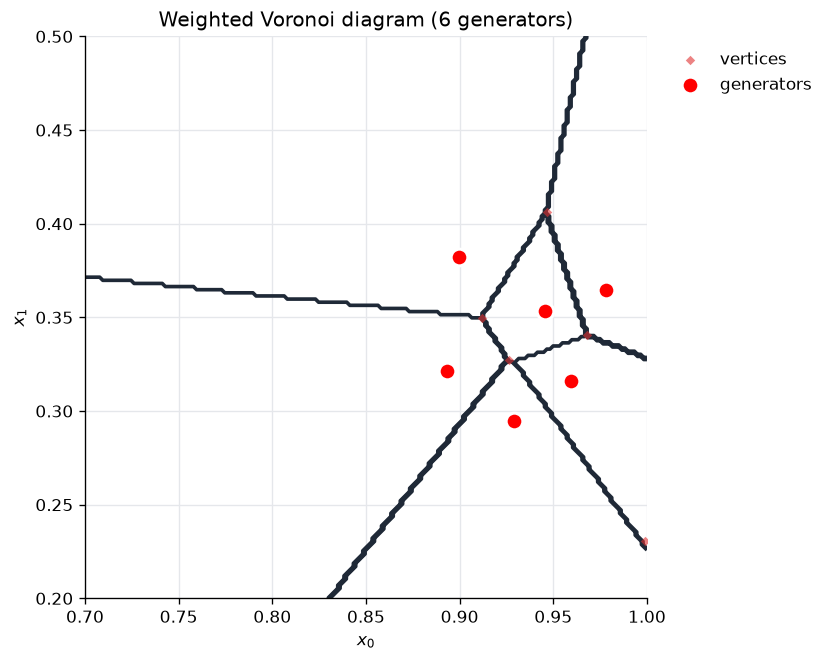

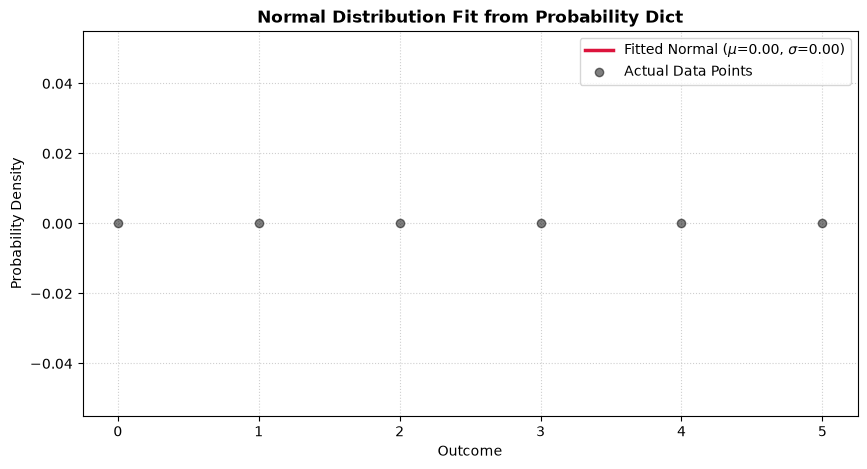

torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])
tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor(

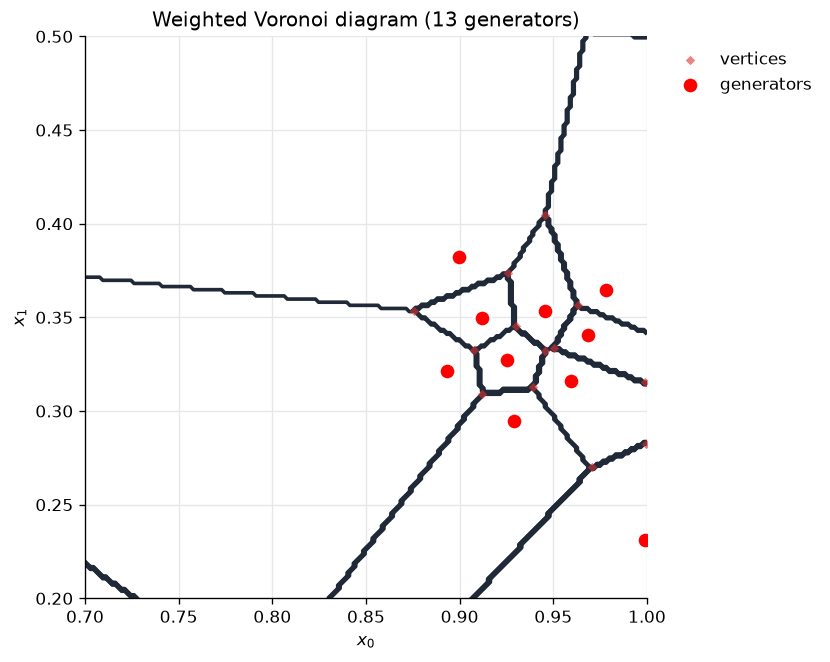

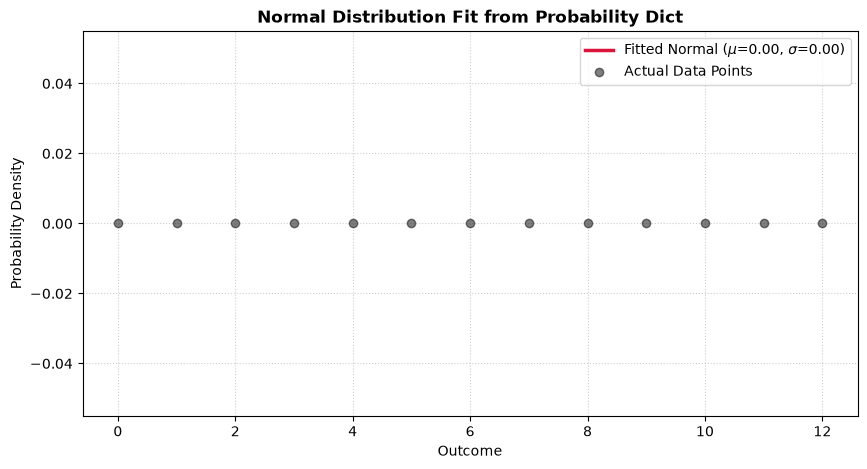

COMPUTED - problem: (williams_otto), algorithm: (custom_voronoiv1_default), seed: (2)  elapsed: 32.46 sec
  best_f: (-90.87965098640655)
  f_list: ([113.3913322475205, 89.38669510012528, 104.36598536521603, 63.617313534251934, 92.60603947719585, 88.0325145158746, 105.38582588618476, 81.52063784224686, 111.68514550710813, 63.35498629690005, 83.67826547665936, 91.16158571144854, 110.24024091605008, 90.15186719152643, 102.59826276450804, 69.26264928760747, 88.20224224522076, 80.98926816742528, 83.54291821397248, 88.41979979559403, 86.0250731401452, 153.6356026385306, 157.38580562439643, -88.6651693781372, 17.490505338535286, 105.80734133150975, 87.62093715557307, 105.39248022014499, 62.9590645613614, 83.08151735171373, 91.58470195707707, 89.15814596744247, 87.07214844361147, 93.02033667096873, 161.34633092302283, 152.0531057096864, -83.70254895187361, 24.028481011322924, 91.75545312202917, 86.37160778271937, 102.85754228360327, 60.71771889569686, 89.37887947052184, 99.83058242448703, 86.1

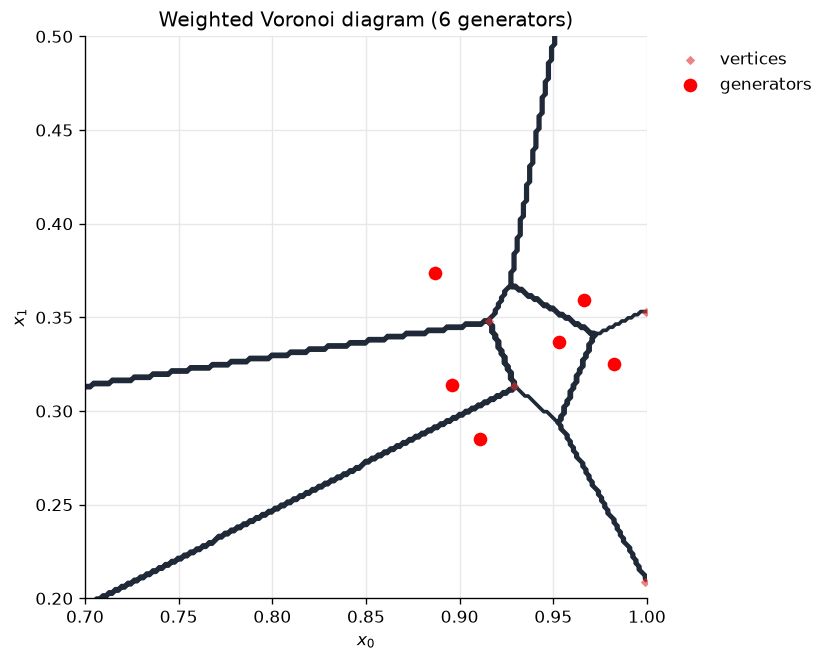

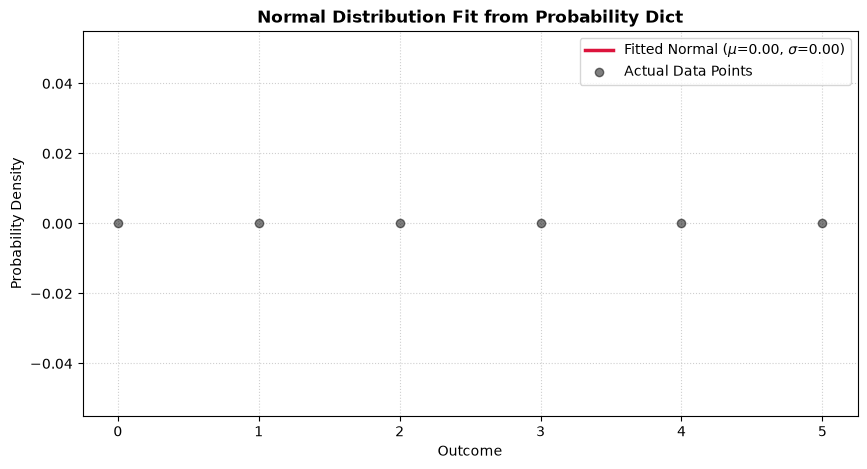

torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
torch.Size([20000]) tensor([False,  True]) tensor([False,  True])
tensor([False])
tensor([False])
tensor([False,  True])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False,  True])
tensor([False])
tensor([False,  Tr

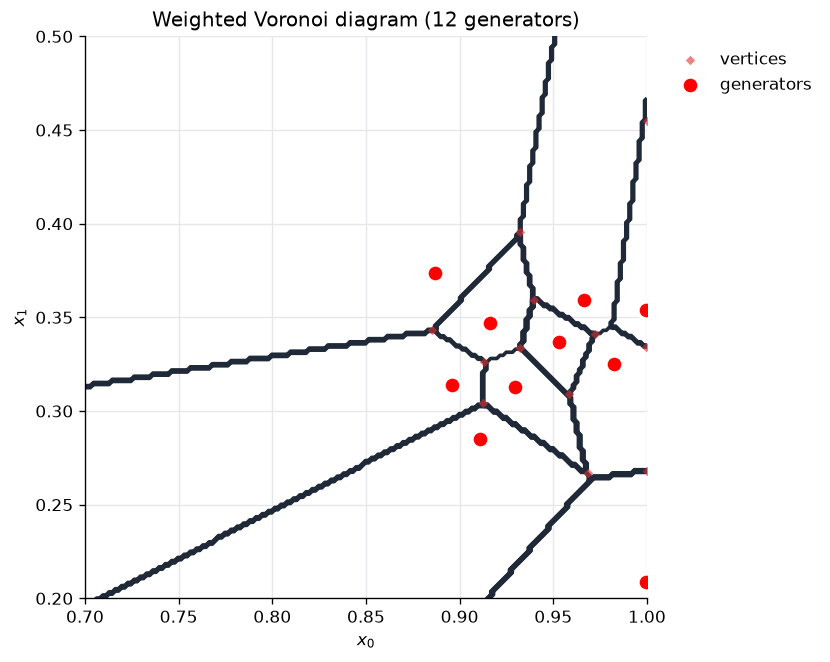

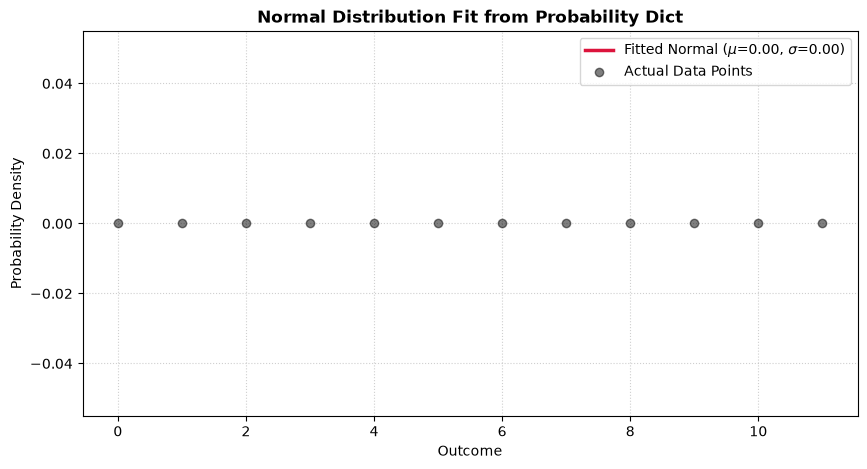

COMPUTED - problem: (williams_otto), algorithm: (custom_voronoiv1_default), seed: (3)  elapsed: 33.25 sec
  best_f: (-83.99823127550962)
  f_list: ([97.95991782171154, 90.76116050813437, 65.87159350137415, 98.78652596359962, 92.24935818546408, 83.5329957706872, 103.70839046495996, 101.38127698351116, 68.68212502983567, 118.2175468878969, 87.2163234694732, 89.20625802004213, 99.96585200973004, 97.27474082451522, 67.76302752542085, 104.71067509763645, 89.62220755186274, 85.9761654786414, 94.18815597966284, 73.95314666874003, 92.51768481574823, 3.5894912765769504, 156.78553003966113, 53.90089258034425, 91.59057612664401, 109.87785695453692, 65.44849132846605, 98.80686880554299, 84.43615391051719, 82.57161685179074, 103.85417784768038, 72.14322523136207, 102.99692174394227, 6.5880579570682585, 156.71629697575383, 58.92846852782873, 96.40688888793079, 111.9602824967867, 73.42626681320928, 103.79700046651237, 89.88986339600535, 85.811857399151, 100.70021173250791, 85.85789940783661, 92.76081

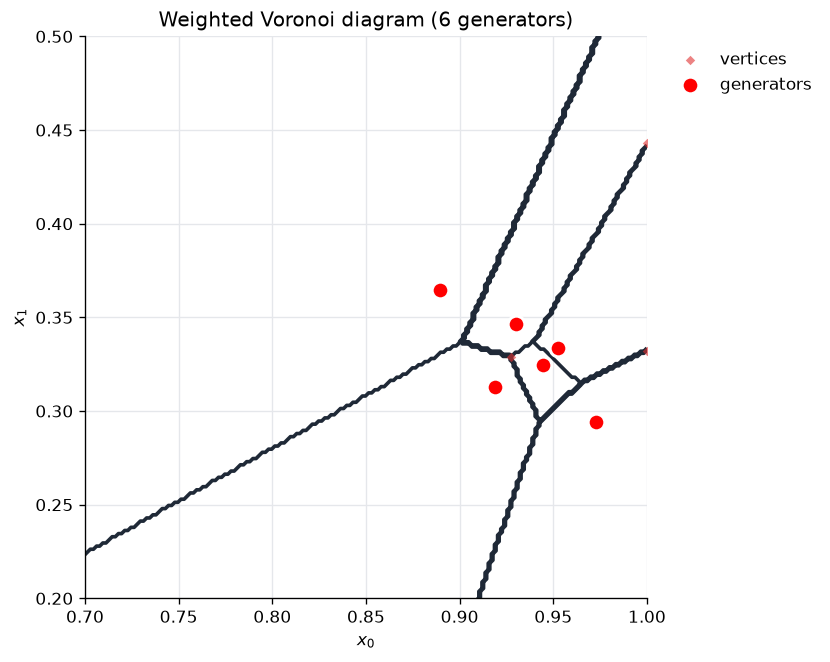

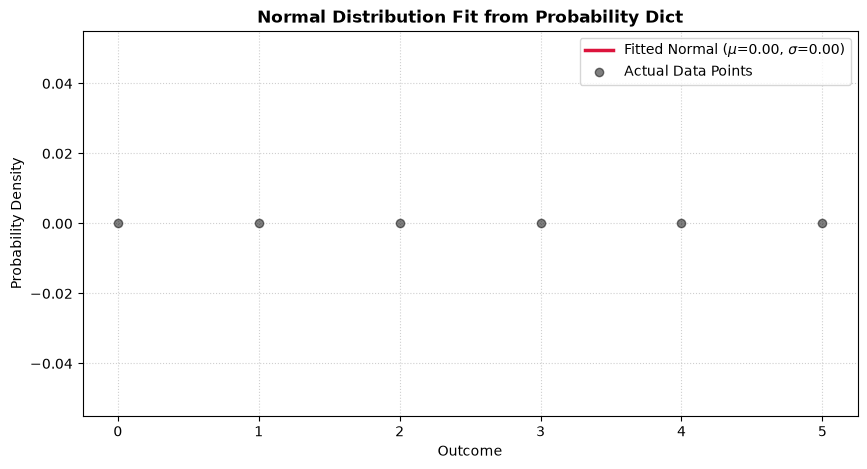

torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
torch.Size([20000]) tensor([False,  True]) tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
tensor([False])
{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0}


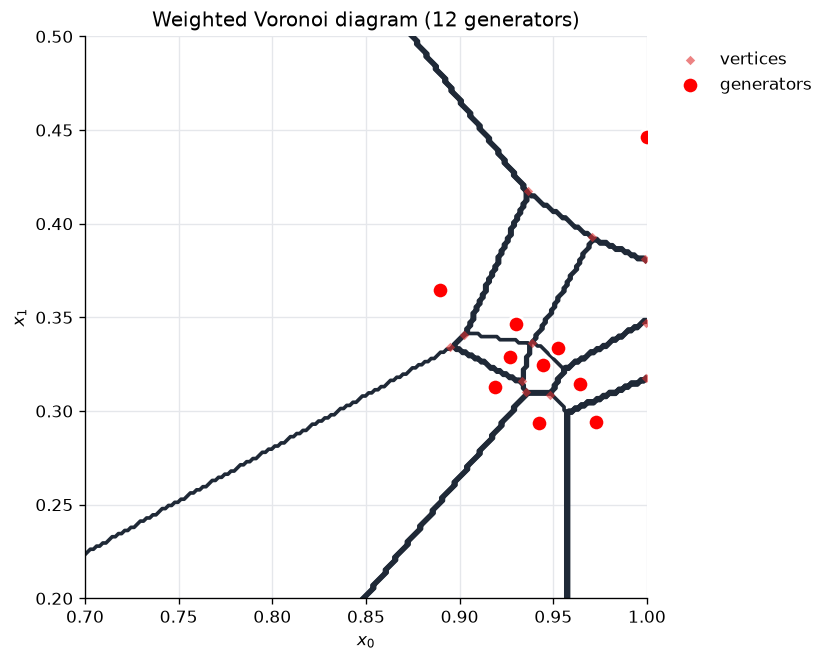

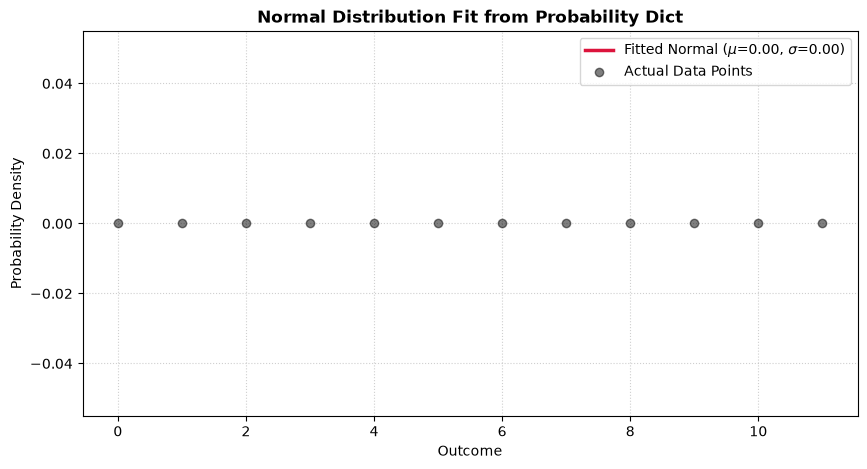

Loading problems...: 100%|██████████| 1/1 [02:09<00:00, 129.33s/it]

COMPUTED - problem: (williams_otto), algorithm: (custom_voronoiv1_default), seed: (4)  elapsed: 20.84 sec
  best_f: (-76.44317852327788)
  f_list: ([113.26077656832524, 66.10928862421326, 83.42040618586418, 99.23858627592745, 101.21913210795492, 79.30331325350744, 117.19592165757058, 70.65374727707649, 91.39214579768691, 88.36697190561824, 95.7025950733854, 90.82572237510476, 110.78740124227272, 67.63018861714806, 94.84663996187248, 99.1197147020174, 96.86732035659679, 80.54348235656164, 88.91486540801475, 76.88497767936065, 95.97110393069806, 106.74967956515763, 57.1607419779981, 33.66642727456144, 117.89008130937543, 71.6614843665734, 96.72970060675107, 95.19806692236307, 100.94068131323513, 80.64515418037024, 90.59275494285009, 71.14448523707097, 110.77582976749079, 101.63150692732665, 50.82230985383978, 33.649560984533196, 113.96356347024482, 71.47952863368744, 101.13766798596191, 99.46908121664023, 92.75711256004013, 83.97791383211802, 93.26413781717861, 68.41163642691868, 106.135

In [3]:
problems: list[tuple[int, list[type]]] = \
    [
        #Sphere,
        #(2, [ExothermicCstr]),
        #(3, [PidTuning]),
        (2, [WilliamsOtto])
    ]
algorithms: list[Callable] = \
    [
        #random_search,
        #safeopt,
        goose,
        
    ]
algorithms.extend(cached_custom_algorithms)

cache: ExperimentCache | None = None #ExperimentCache("cache_all_100_violations")
#results: BenchmarkResults = run_benchmark(
#    problems=problems,1
#    algorithms=algorithms,
#    n_x=2, seeds=range(10), max_evals=(100), cache=cache, verbose=True
#)

result_baseline: BenchmarkResults = BenchmarkResults()
result_custom: BenchmarkResults = BenchmarkResults()

from tqdm import tqdm

for (n_x, prblms) in tqdm(problems, desc=f"Loading problems..."):
    print("Ran non-cached algorithms: ", algorithms)
    result_baseline += run_benchmark(
        problems=prblms,
        algorithms=algorithms,
        n_x=n_x, seeds=range(10), max_evals=(100), cache=ExperimentCache("baseline_cache"), verbose=True
    )
    if not custom_algorithms:
        continue
    print(f"Ran Cached algorithms: {custom_algorithms}")
    result_custom += run_benchmark(
        problems=prblms,
        algorithms=custom_algorithms,
        n_x=n_x, seeds=range(5), max_evals=(100), cache=None, verbose=True
    )

[<Figure size 550x380 with 1 Axes>]

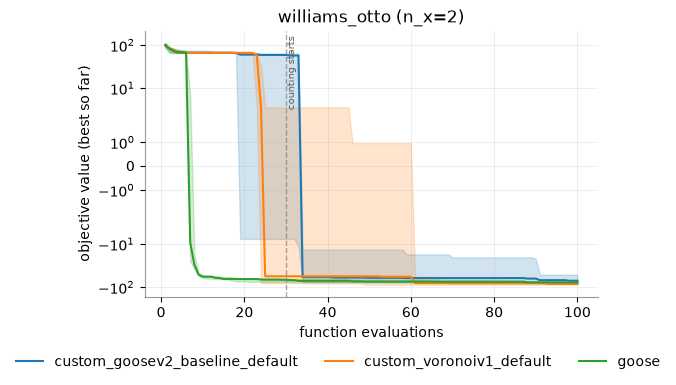

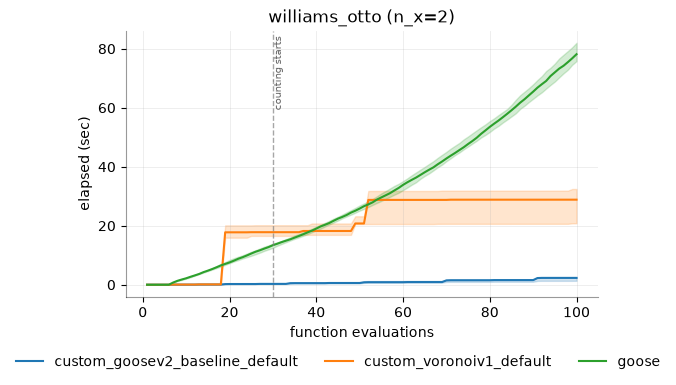

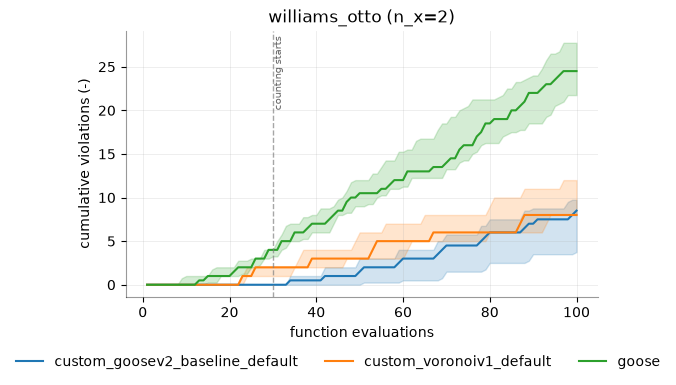

In [4]:
from safebo_simpl.wrappers.ddosuite_graphing import (
    plot_all_convergence,
    plot_all_elapsed,
    plot_all_cumulative_elapsed,
    plot_all_cumulative_violations,
)

agg = aggregate_results(results=result_baseline + result_custom, ignore_nonexistent_attributes=False)
plot_all_convergence(agg)
plot_all_elapsed(agg, log_y=False)
plot_all_cumulative_violations(agg)
